
<center>

# Malaria Diagnosis Prediction Using Logistic Regression with SGD

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 10 Optimization in Machine Learning with Stochastic Gradient Descent
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>

### The imported libraries
``pandas`` and ``numpy`` for data handling  
``matplotlib`` for plots  
``gdown`` to download the Malaria Dataset CSV  hosted in my Google Drive  
``scikit-learn`` tools for preprocessing, modeling, and evaluation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, log_loss, ConfusionMatrixDisplay
)

### Downloading and loading the dataset
The dataset used in this project is the Malaria Diagnosis Dataset, originally obtained from [Kaggle](https://www.kaggle.com/datasets/programmer3/malaria-diagnosis-dataset) and stored on my Google Drive for convenient access. It is downloaded using `gdown` and then loaded into pandas for further inspection and preprocessing. This approach improves accessibility, reproducibility, and ease of use when the notebook is executed in different environments.

In [11]:
# Google Drive file download
file_id = "18MUwSLlr7f5MIFsySmtoq8YLmrhjIKzH"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "Malaria_Dataset.csv", quiet=False)

# Load dataset
df = pd.read_csv("Malaria_Dataset.csv")

# Preview first rows
df.head()

Downloading...
From: https://drive.google.com/uc?id=18MUwSLlr7f5MIFsySmtoq8YLmrhjIKzH
To: /home/langstkip/workspace/myOUK_Masters/MLS-SEM2/CSA821/Malaria_Dataset.csv
100%|██████████| 208k/208k [00:00<00:00, 463kB/s]


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


### Inspecting the dataset

In [12]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset info:")
df.info()

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (1622, 21)

Columns:
['IP_Number', 'Age', 'Sex', 'Residence_Area', 'DOA', 'Discharge_Date', 'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise', 'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain', 'Coughing', 'Joint_Pain', 'Primary_Code', 'Diagnosis_Type', 'Target', 'Risk_Score']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   IP_Number             1622 non-null   str  
 1   Age                   1622 non-null   int64
 2   Sex                   1622 non-null   str  
 3   Residence_Area        1622 non-null   str  
 4   DOA                   1622 non-null   str  
 5   Discharge_Date        1622 non-null   str  
 6   Fever                 1622 non-null   int64
 7   Headache              1622 non-null   int64
 8   Abdominal_Pain        1622 non-null   int64
 9   General_Body_Malaise  1622 

### Initial data cleaning

In [13]:
# Drop identifier column if it exists
df = df.drop(columns=["IP_Number"], errors="ignore")

# Convert date columns to datetime
df["DOA"] = pd.to_datetime(df["DOA"], errors="coerce", dayfirst=True)
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], errors="coerce", dayfirst=True)

# Check converted dates
df[["DOA", "Discharge_Date"]].head()

,DOA,Discharge_Date
0,2015-10-31 20:42:00,2015-11-05 05:16:00
1,2015-02-03 23:28:00,2015-02-13 19:27:00
2,2019-11-15 12:31:00,2019-11-19 14:31:00
3,2017-05-17 17:50:00,2017-05-23 13:22:00
4,2015-06-26 15:29:00,2015-06-27 23:35:00


### Feature engineering

In [14]:
# Create length of stay in hours
df["Length_of_Stay_Hours"] = (
    (df["Discharge_Date"] - df["DOA"]).dt.total_seconds() / 3600
)

# Preview new feature
df[["DOA", "Discharge_Date", "Length_of_Stay_Hours"]].head()

# Drop raw date columns
df = df.drop(columns=["DOA", "Discharge_Date"], errors="ignore")

### Define the target and predictors

The project is a binary classification problem:

`Target` = `1` means malaria diagnosis  
`Target` = `0` means no malaria diagnosis

The dataset is therefore split into:

`features (X)`: all predictor variables  
`target (y)`: the diagnosis outcome to be predicted


In [29]:
# Keep a fresh raw copy
raw_df = pd.read_csv("Malaria_Dataset.csv")
df = raw_df.copy()

# Drop identifier column if it exists
df = df.drop(columns=["IP_Number"], errors="ignore")

# Convert date columns to datetime
df["DOA"] = pd.to_datetime(df["DOA"], errors="coerce", dayfirst=True)
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], errors="coerce", dayfirst=True)

# Create length of stay in hours
df["Length_of_Stay_Hours"] = (
    (df["Discharge_Date"] - df["DOA"]).dt.total_seconds() / 3600
)

# Drop raw date columns
df = df.drop(columns=["DOA", "Discharge_Date"], errors="ignore")

# Define target and predictors
target_col = "Target"
X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1622, 18)
Shape of y: (1622,)


### Identify numerical and categorical features

The dataset contains both numerical and categorical variables. These need different preprocessing approaches before model training. Numerical features will be imputed and scaled, while categorical features will be imputed and one-hot encoded.

In [38]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

### Preprocessing the features
To prepare the dataset for machine learning:  
a) Missing numerical values are replaced with the median  
b) Numerical values are standardized using StandardScaler  
c) Missing categorical values are replaced with the most frequent value  
d) Categorical variables are converted into numeric form using one-hot encoding

In [31]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor for full feature set
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### Splitting the dataset into training and testing sets
The dataset is split into training and testing sets using an 80:20 ratio. The `stratify=y` parameter ensures that the class distribution remains similar in both subsets.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1297, 18)
Testing set shape: (325, 18)


### Building the Logistic Regression model with SGD

This is implemented using `SGDClassifier` with `loss="log_loss"`, which makes it behave as Logistic Regression trained through Stochastic Gradient Descent.

In [33]:
sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

### Modeling Pipeline
A pipeline is used to combine preprocessing and classification into one workflow. This ensures that the same transformations are applied consistently during both training and testing.

In [34]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", sgd_model)
])

### Training the models
The SGD Logistic Regression model is then trained using the training dataset.

In [35]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Evaluating the model

To assess performance, the following evaluation metrics are used accuracy, precision, recall, F1-score, log loss, and confusion matrix. These metrics provide a more complete picture of classification performance than accuracy alone.


SGD Logistic Regression
-----------------------
Accuracy : 0.9938
Precision: 0.9915
Recall   : 1.0000
F1-score : 0.9957
Log Loss : 0.0166

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        91
           1       0.99      1.00      1.00       234

    accuracy                           0.99       325
   macro avg       1.00      0.99      0.99       325
weighted avg       0.99      0.99      0.99       325



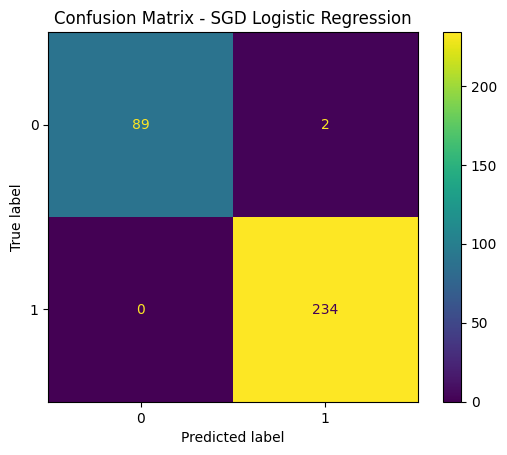

In [37]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    loss = log_loss(y_test, y_prob)

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Log Loss : {loss:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "log_loss": loss
    }

results = evaluate_model(
    pipeline, X_test, y_test,
    "SGD Logistic Regression"
)

### Results and discussion

The SGD-based Logistic Regression model achieved very strong performance on the malaria diagnosis dataset. The model recorded an accuracy of 99.38%, precision of 99.15%, recall of 100%, F1-score of 99.57%, and log loss of 0.0166. These results indicate that the model was highly effective in distinguishing malaria-positive cases from non-malaria cases.

The recall of 100% is particularly important in a medical classification setting because it shows that all actual malaria-positive cases in the test dataset were correctly identified. This reduces the likelihood of false negatives, which is critical in disease diagnosis where missed cases can have serious health implications.

The classification report further confirms the strength of the model. For class 1 representing malaria diagnosis, the model achieved precision of 0.99 and recall of 1.00, showing that almost all predicted malaria cases were correct and that no malaria-positive cases were missed. For class 0, the model also performed well, with precision of 1.00 and recall of 0.98, indicating very few false positives and false negatives.

The very low log loss value of 0.0166 suggests that the model’s predicted probabilities were also highly confident and well aligned with the true outcomes. In essence, the results show that Logistic Regression optimized using Stochastic Gradient Descent can be highly effective for binary medical diagnosis tasks when informative predictors are available.

A possible limitation, however, is that Risk_Score may already summarize part of the symptom-based information in the dataset. This may strengthen predictive performance and should be acknowledged when interpreting the findings.

### Conclusion

This project implemented a malaria diagnosis prediction model using Logistic Regression optimized through Stochastic Gradient Descent. The dataset was downloaded from my Google Drive, inspected, cleaned, and transformed through feature engineering and preprocessing. The trained model achieved excellent classification performance, with particularly strong recall for malaria-positive cases. This demonstrates that SGD-based Logistic Regression is an effective method for binary classification problems in healthcare, especially when relevant clinical and diagnostic features are included.